# Importing Modules

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import numpy as np

import torch

# Check if CUDA (NVIDIA) is available
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# Check if MPS (Apple Silicon) is available
print("MPS available:", torch.backends.mps.is_available())

CUDA available: True
CUDA device count: 1
GPU name: NVIDIA GeForce RTX 3070 Laptop GPU
MPS available: False


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bwandowando/globe-gcash-google-app-reviews")
file_name = 'GCASH_REVIEWS.csv'

df = pd.read_csv(path + '/' + file_name)

# Quick Look at the Data Structure

In [8]:
df.head()

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
0,0,Works fine.. I like the graphics and layout.. ...,5,NaN,A Google user,1.0.1.0,2012-03-26T05:49:59.000Z,4
1,1,"""Unknown error occurred"" always popping up! Ne...",1,NaN,A Google user,1.0.0.0,2012-03-26T10:49:57.000Z,0
2,2,very convenient to use..,5,NaN,A Google user,1.0.1.0,2012-05-08T03:32:34.000Z,0
3,3,"It would really be great if you add ""payable t...",4,NaN,A Google user,1.0.1.0,2012-05-31T13:53:30.000Z,7
4,4,Its working fine with my motorola droid razr. ...,5,NaN,A Google user,1.0.1.0,2012-06-20T13:38:43.000Z,1


In [9]:
df.tail()

,Unnamed: 0,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
592598,592598,Very good,5,115946*********032880,A Google user,5.69.1,2023-11-13T16:25:20.000Z,0
592599,592599,The app is missig,1,112495*********423378,A Google user,5.70.0,2023-11-13T16:40:15.000Z,0
592600,592600,The app is gone on my phone without even unins...,2,115479*********316557,A Google user,5.70.0,2023-11-13T16:40:54.000Z,0
592601,592601,Love it,5,108579*********021270,A Google user,NaN,2023-11-13T16:42:51.000Z,0
592602,592602,"Gaudy, messy, tries to force me to turn off de...",1,116742*********619116,A Google user,5.69.3,2023-11-13T16:45:07.000Z,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 592603 entries, 0 to 592602
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           592603 non-null  int64
 1   review_text          592203 non-null  str  
 2   review_rating        592603 non-null  int64
 3   author_id            592570 non-null  str  
 4   author_name          592603 non-null  str  
 5   author_app_version   461864 non-null  str  
 6   review_datetime_utc  592603 non-null  str  
 7   review_likes         592603 non-null  int64
dtypes: int64(3), str(5)
memory usage: 36.2 MB


In [11]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_rating,592603.0,3.557603,1.760913,1.0,1.0,5.0,5.0,5.0
review_likes,592603.0,1.555314,64.754417,0.0,0.0,0.0,0.0,17198.0


# Data Cleaning

Before any NLP, we always do these 4 things:
1. **Drop rows with no review text** — can't do NLP without text
2. **Ensure correct data types** — ratings should be integers, not strings
4. **Filter out junk** — 1-character reviews add no signal

In [13]:
df.isna().sum()

review_text               400
review_rating               0
author_id                  33
author_name                 0
author_app_version     130739
review_datetime_utc         0
review_likes                0
dtype: int64

In [14]:
# Drop
df = df.dropna(subset=[
            'review_text', 
            'author_id', 
            'author_app_version'
        ]).copy() # dropping rows with no values

# Ensure Correct Data types
df['review_datetime_utc'] = pd.to_datetime(df['review_datetime_utc'], errors='coerce')


# Remove very short reviews — 'ok', 'good' etc. don't have enough signal
df = df[df['review_text'].str.len() >= 10].reset_index(drop=True)



In [15]:
df.isna().sum()

review_text            0
review_rating          0
author_id              0
author_name            0
author_app_version     0
review_datetime_utc    0
review_likes           0
dtype: int64

# Exploratory Data Analysis

In [16]:
df.dtypes

review_text                            str
review_rating                        int64
author_id                              str
author_name                            str
author_app_version                     str
review_datetime_utc    datetime64[us, UTC]
review_likes                         int64
dtype: object

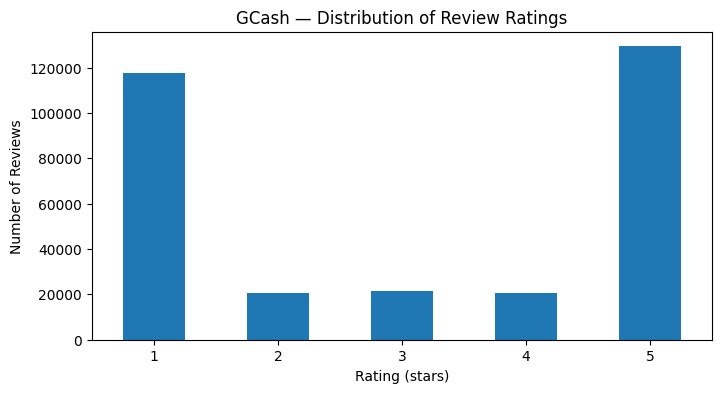


Average rating: 3.08 ★
% of 1-star reviews: 37.9%
% of 5-star reviews: 41.8%


In [17]:
# Rating distribution
plt.figure(figsize=(8, 4))
df['review_rating'].value_counts().sort_index().plot(kind='bar')

plt.title('GCash — Distribution of Review Ratings')
plt.xlabel('Rating (stars)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

print(f"\nAverage rating: {df['review_rating'].mean():.2f} ★")
print(f"% of 1-star reviews: {(df['review_rating']==1).mean()*100:.1f}%")
print(f"% of 5-star reviews: {(df['review_rating']==5).mean()*100:.1f}%")

# Downsampling for Speed and Save Token

In [18]:
SAMPLE_SIZE = 1000
columns = df.columns

df_sampled = df.groupby('review_rating', group_keys=True).apply(
    lambda x: x.sample(
        n=max(1, int(round(SAMPLE_SIZE * len(x) / (len(df) + 1)))),
        random_state=42
    )
).reset_index()

df_sampled.to_csv('../data/GCASH_REVIEW_SAMPLED.csv', index=False)

In [19]:
df_sampled = df_sampled[columns]

In [20]:
df_sampled.index

RangeIndex(start=0, stop=1001, step=1)

In [21]:
df_sampled.head(2)

,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes
0,Gcash WALANG KWENTA TO PAG NAWALA PERA MO..BAH...,1,117757*********258906,A Google user,5.54.0,2022-07-04 05:10:11+00:00,0
1,accounts have been compromised and account's b...,1,112254*********734322,A Google user,5.64.1,2023-05-27 12:48:02+00:00,0


In [22]:
df_sampled['review_rating'].value_counts(normalize=True).sort_index() * 100

review_rating
1    37.862138
2     6.693307
3     6.993007
4     6.693307
5    41.758242
Name: proportion, dtype: float64

# Sentiment Analysis
The model: nlptown/bert-base-multilingual-uncased-sentiment.

What it is: A BERT-base model fine-tuned on a large dataset of multilingual reviews (Yelp, etc.). Unlike Twitter-specific models, it is optimized for consumer feedback and rating-style sentiment.

Output: 5 labels (Star Ratings) + confidence score.

1 star & 2 stars → Negative

3 stars → Neutral

4 stars & 5 stars → Positive

Language note for Philippine context
Since this model is explicitly multilingual (trained on English, Spanish, French, German, Italian, and Chinese), its behavior in the Philippine context is unique:

✅ Strong English Support: Handles formal and informal English reviews with high accuracy.

✅ Multilingual Logic: Because it is "multilingual-uncased," it is much better at capturing the semantic meaning of Taglish than an English-only RoBERTa model.

⚠️ Tagalog Nuance: While not explicitly trained on Tagalog, the multilingual architecture often "transfers" understanding from related structures, though it may still struggle with deep Tagalog slang (e.g., "napakasablay").

In [23]:
sentiment_model = "nlptown/bert-base-multilingual-uncased-sentiment"
sentiment_classifier = pipeline(
    "sentiment-analysis",
    model=sentiment_model,
    truncation=True,
    max_length=512,
    batch_size=32,
    device=0,
    torch_dtype=torch.float16
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [24]:
# Sanity check — test it on a couple of reviews before running on the whole dataset
test_reviews = [
    "Galing talaga ng GCash, super convenient!",
    "Worst app ever, my balance disappeared and no one can help.",
    "It's okay I guess, sometimes works sometimes doesn't."
]
for t in test_reviews:
    result = sentiment_classifier(t)[0]
    print(f"{result['label']} ({result['score']:.2f}) → {t}")

5 stars (0.74) → Galing talaga ng GCash, super convenient!
1 star (0.92) → Worst app ever, my balance disappeared and no one can help.
3 stars (0.83) → It's okay I guess, sometimes works sometimes doesn't.


In [25]:
sentiment_results = sentiment_classifier(df_sampled['review_text'].tolist())

In [26]:
df_sampled['sentiment'] = [x['label'] for x in sentiment_results]
df_sampled['sentiment_score'] = [x['score'] for x in sentiment_results]

In [27]:
df_sampled

,review_text,review_rating,author_id,author_name,author_app_version,review_datetime_utc,review_likes,sentiment,sentiment_score
0,Gcash WALANG KWENTA TO PAG NAWALA PERA MO..BAH...,1,117757*********258906,A Google user,5.54.0,2022-07-04 05:10:11+00:00,0,1 star,0.339820
1,accounts have been compromised and account's b...,1,112254*********734322,A Google user,5.64.1,2023-05-27 12:48:02+00:00,0,1 star,0.549079
2,Can't login..,1,113197*********263810,Na************ia,5.33.0,2023-10-19 05:01:00+00:00,0,1 star,0.666013
3,Lagi iuupdate kahit nkaupdate na!!!,1,102604*********004212,A Google user,5.52.0,2022-05-26 06:54:13+00:00,0,1 star,0.432981
4,It's so hard to fully verified my acount. I'm ...,1,112139*********224938,A Google user,5.40.0,2021-05-28 06:00:24+00:00,0,2 stars,0.515127
...,...,...,...,...,...,...,...,...,...
996,Very nice app very easy and user friendly,5,105206*********739808,A Google user,5.43.0,2021-08-19 13:05:35+00:00,1,5 stars,0.716906
997,Puro update,5,111407*********785738,A Google user,5.46.1,2021-12-12 03:09:28+00:00,0,5 stars,0.431351
998,nice update,5,107544*********398472,A Google user,5.19.4,2019-11-09 02:57:41+00:00,0,4 stars,0.457325
999,Very nice app,5,111920*********627995,A Google user,5.24.0,2020-01-17 23:07:33+00:00,0,5 stars,0.661596


In [28]:
label_meaning = {
    "1 star": "Very negative",
    "2 stars": "Negative",
    "3 stars": "Neutral",
    "4 stars": "Positive",
    "5 stars": "Very Positive"
}
df_sampled['sentiment_meaning'] = df_sampled['sentiment'].map(label_meaning)

In [29]:
df_sampled.columns

Index(['review_text', 'review_rating', 'author_id', 'author_name',
       'author_app_version', 'review_datetime_utc', 'review_likes',
       'sentiment', 'sentiment_score', 'sentiment_meaning'],
      dtype='str')

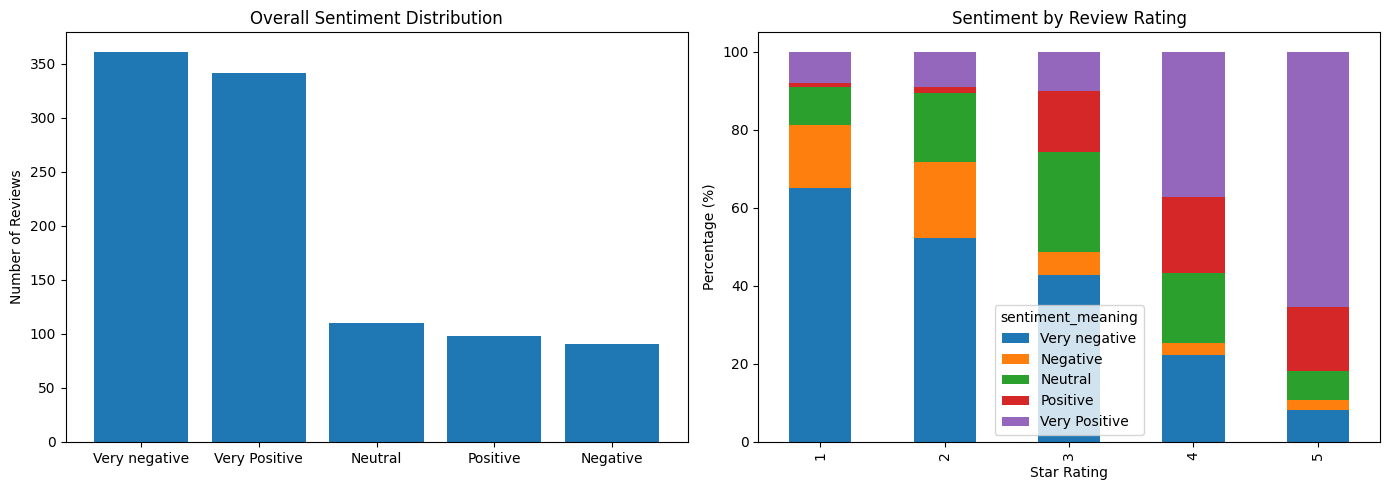

In [30]:
# Visualize sentiment results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: overall sentiment split
sentiment_counts = df_sampled['sentiment_meaning'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values)
axes[0].set_title('Overall Sentiment Distribution')
axes[0].set_ylabel('Number of Reviews')

# Plot 2: sentiment within each star rating — sanity check
sentiment_by_rating = pd.crosstab(df_sampled['review_rating'], df_sampled['sentiment_meaning'], normalize='index') * 100
sentiment_by_rating = sentiment_by_rating[list(label_meaning.values())] 
sentiment_by_rating.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Sentiment by Review Rating')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Star Rating')

plt.tight_layout()
plt.show()

### 💡 Interpreting the sentiment results
- **1-star reviews mostly Negative + 5-star reviews mostly Positive** → model is working ✅
- **Interesting mismatches:** 1-star reviews tagged as Positive usually mean the model struggled with Tagalog, OR the user was being sarcastic ("Ang galing talaga na hindi ako makabili!")
- **Neutral reviews:** often mixed feedback ("Good app pero madalas crash")

# Feature Engineering for Clustering

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Engineered feature from the review text
df_sampled['review_length'] = df['review_text'].str.len()
df_sampled['word_count'] = df_sampled['review_text'].str.split().str.len()

df_sampled[['review_length', 'word_count']].describe()

,review_length,word_count
count,1001.000000,1001.000000
mean,104.966034,14.477522
std,104.912711,18.076663
min,10.000000,1.000000
25%,33.000000,4.000000
50%,68.000000,7.000000
75%,139.000000,18.000000
max,925.000000,153.000000


In [ ]:
# Pick which columns to feed into the clustering pipeline
numeric_features = ['review_rating', 'sentiment_score', 'review_length', 'word_count']

categorical_features = ['sentiment']

# Numeric pipeline: impute → scale (sequential, correct order)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # fill missing with median
    ('scaler', StandardScaler())                      # scale to mean=0, std=1
])

# Categorical pipeline: one-hot encoding (Negative/Neutral/Positive → 3 binary columns)
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both into a single ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Apply the transformation
X = preprocessor.fit_transform(df_sampled)

# If sparse matrix (from OneHotEncoder), convert to dense for PCA
if hasattr(X, 'toarray'):
    X = X.toarray()

print(f"Feature matrix shape: {X.shape}  (rows, features)")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Feature matrix shape: (1001, 9)  (rows, features)
Numeric features: ['review_rating', 'sentiment_score', 'review_length', 'word_count']
Categorical features: ['sentiment']


---
## Dimensionality Reduction with PCA

### Why reduce to 2D?
1. **Visualization** — can't plot 8 dimensions, can plot 2
2. **Cleaner clustering** — KMeans is more effective in lower dimensions
3. **Noise reduction** — PCA naturally filters minor variations

### What PCA actually does
Finds the 2 directions ("principal components") that capture the most **variance** in the data. These 2 directions become our new X/Y axes.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# How much information did the 2D representation preserve?
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
total_var = var_pc1 + var_pc2

print(f"Variance preserved by 2 components: {total_var:.1f}%")
print(f"  PC1: {var_pc1:.1f}%")
print(f"  PC2: {var_pc2:.1f}%")
print("\n💡 Rule of thumb: 50%+ is reasonable for visualization")

Variance preserved by 2 components: 55.2%
  PC1: 31.3%
  PC2: 23.9%

💡 Rule of thumb: 50%+ is reasonable for visualization


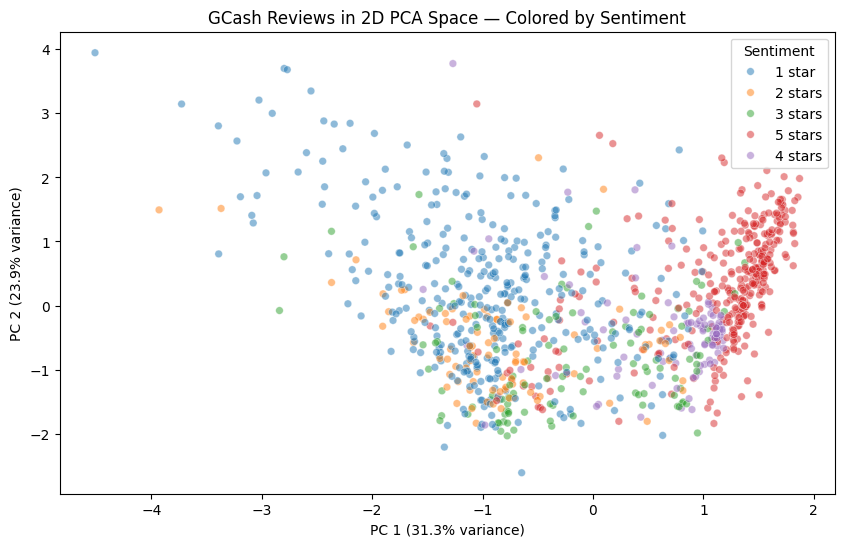

In [ ]:
# Visualize the 2D projection, colored by sentiment
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_sampled['sentiment'],
    s=30, alpha=0.5
)
plt.xlabel(f'PC 1 ({var_pc1:.1f}% variance)')
plt.ylabel(f'PC 2 ({var_pc2:.1f}% variance)')
plt.title('GCash Reviews in 2D PCA Space — Colored by Sentiment')
plt.legend(title='Sentiment')
plt.show()

---
## KMeans Clustering

### Goal
Find **natural groups of customers** without using any labels. This reveals segments we might not have thought of — maybe "power users who encounter bugs", "first-time users who are confused", etc.

### Picking the number of clusters (`k`)
Use the **Elbow Method**: plot inertia (sum of squared distances from each point to its cluster center) against `k`. Look for the "bend" — that's usually the optimal `k`.

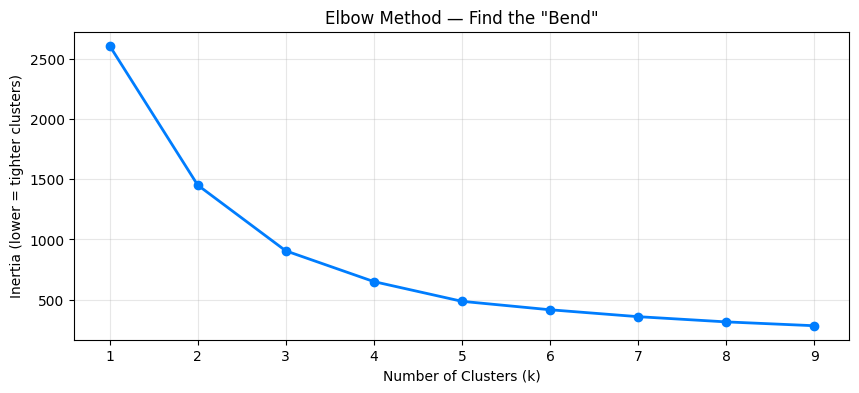

In [ ]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='#007dfe', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method — Find the "Bend"')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

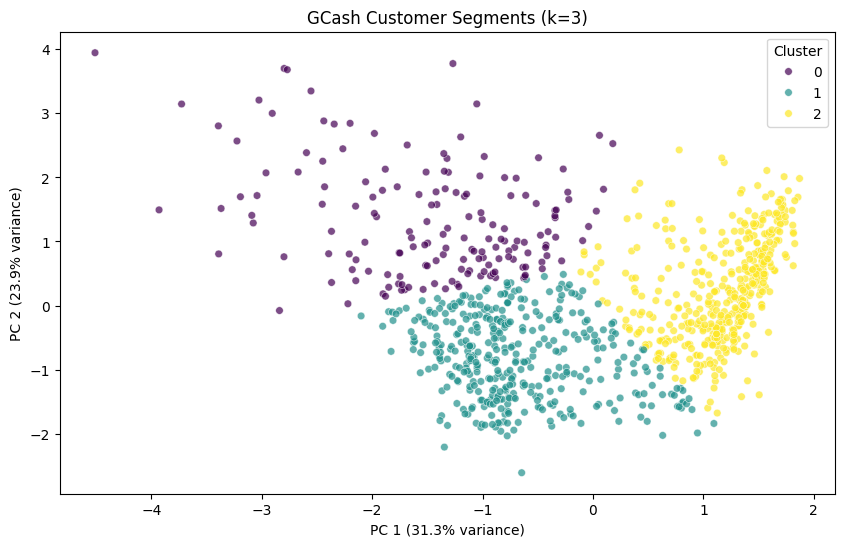

In [ ]:
# Pick k based on the elbow. 4 is common for reviews:
# happy, neutral, frustrated, very angry.
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_sampled['cluster'] = kmeans.fit_predict(X_pca)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_sampled['cluster'], palette='viridis',
    s=30, alpha=0.7
)
plt.xlabel(f'PC 1 ({var_pc1:.1f}% variance)')
plt.ylabel(f'PC 2 ({var_pc2:.1f}% variance)')
plt.title(f'GCash Customer Segments (k={OPTIMAL_K})')
plt.legend(title='Cluster')
plt.show()

In [ ]:
# Profile each cluster — what characterizes the average customer in each group?
profile_cols = ['review_rating', 'sentiment_score', 'review_length', 'word_count']

cluster_profile = df_sampled.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile['n_reviews'] = df_sampled.groupby('cluster').size()
cluster_profile['dominant_sentiment'] = df_sampled.groupby('cluster')['sentiment'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
)
cluster_profile

,review_rating,sentiment_score,review_length,word_count,n_reviews,dominant_sentiment
cluster,,,,,,
0,1.58,0.69,81.94,41.43,164,1 star
1,1.81,0.41,119.35,12.15,399,1 star
2,4.79,0.61,100.48,6.50,438,5 stars


# Zero Shot Classification

In [ ]:
# Topics tailored to GCash. Each one should be a clear business theme.
candidate_topics = [
    'App Crashes or Bugs',           # App not working, freezing, errors
    'Account Login Issues',           # OTP, verification, locked out
    'Money Transfer and Cash In',     # Send money, deposit, cash-in problems
    'Payment and Bills',              # Paying merchants, bills, QR payments
    'Customer Service Support',       # Help desk, response time
    'Fees and Charges',               # Service fees, hidden charges
    'Security and Fraud',             # Scams, unauthorized access, hacking
    'User Interface and Experience'   # App design, navigation, ease of use
]



# Load the zero-shot classifier — BART-MNLI is the standard choice
print("Loading zero-shot model... (downloads ~1.6GB on first run)")

# Verify GPU is being used
device = 0 if torch.cuda.is_available() else -1
print(f"Using: {'GPU ✅ ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU ⚠️'}")

topic_classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device,
    torch_dtype=torch.float16
)
print("✅ Zero-shot model loaded")

Loading zero-shot model... (downloads ~1.6GB on first run)
Using: GPU ✅ NVIDIA GeForce RTX 3070 Laptop GPU


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 569.67it/s]


✅ Zero-shot model loaded


In [ ]:
# Testing in one review to see how it works
sample = "Hindi ako ma-login, paulit-ulit ang OTP hindi dumating!"
results = topic_classifier(
    sample,          # full list at once
    candidate_labels=candidate_topics,
    batch_size=32             # tune based on your RAM/GPU
)

print(results)

{'sequence': 'Hindi ako ma-login, paulit-ulit ang OTP hindi dumating!', 'labels': ['Account Login Issues', 'User Interface and Experience', 'Security and Fraud', 'Fees and Charges', 'Money Transfer and Cash In', 'App Crashes or Bugs', 'Customer Service Support', 'Payment and Bills'], 'scores': [0.5460472702980042, 0.20129689574241638, 0.06486671417951584, 0.052096422761678696, 0.04775970056653023, 0.03218984231352806, 0.028742294758558273, 0.02700088731944561]}


In [ ]:
BATCH_SIZE = 64   # Tune up/down based on your VRAM (start at 64, go to 128 if stable)

print(f"Classifying {len(df_sampled):,} reviews on GPU (batch_size={BATCH_SIZE})...")

reviews = df_sampled['review_text'].tolist()

results = topic_classifier(
    reviews,
    candidate_labels=candidate_topics,
    batch_size=BATCH_SIZE,
    hypothesis_template="This GCash review is about {}.",
    truncation=True,      # Handles reviews longer than 1024 tokens
    max_length=512        # BART's practical max
)

# ── Unpack results ─────────────────────────────────────────────────────────────
df_sampled['topic']            = [r['labels'][0]  for r in results]
df_sampled['topic_confidence'] = [r['scores'][0]  for r in results]

print("✅ Topic classification complete!")
print(df_sampled['topic'].value_counts())

Classifying 1,001 reviews on GPU (batch_size=64)...
✅ Topic classification complete!
topic
User Interface and Experience    449
Customer Service Support         123
App Crashes or Bugs              108
Account Login Issues             103
Fees and Charges                  73
Payment and Bills                 70
Money Transfer and Cash In        57
Security and Fraud                18
Name: count, dtype: int64


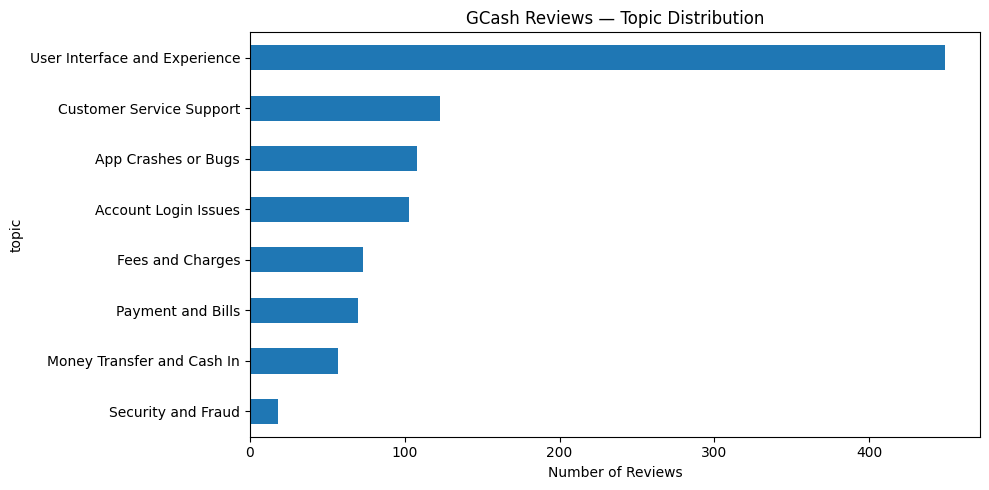

In [ ]:
topic_counts = df_sampled['topic'].value_counts()

plt.figure(figsize=(10, 5))
topic_counts.plot(kind='barh')
plt.title('GCash Reviews — Topic Distribution')
plt.xlabel('Number of Reviews')
plt.gca().invert_yaxis()  # biggest at top
plt.tight_layout()
plt.show()


# Business Insights - Putting it all Together

## Q1: Which topics drive the MOST negative sentiment?

In [ ]:
topic_sentiment = pd.crosstab(df_sampled['topic'], df_sampled['sentiment'], normalize='index') * 100

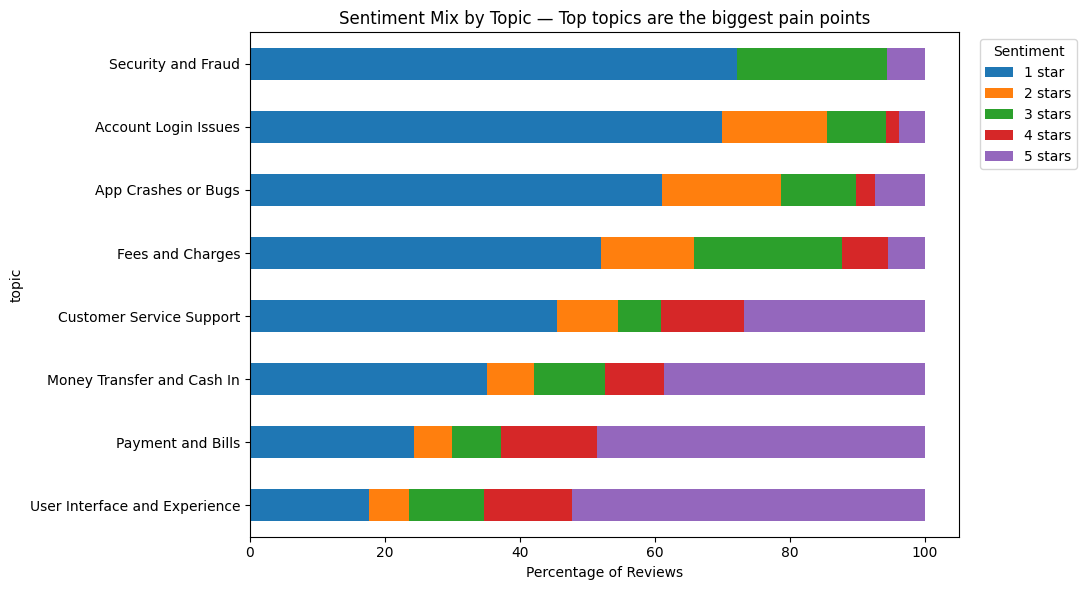

In [ ]:
topic_sentiment = topic_sentiment.sort_values(by='1 star', ascending=False)

ax = topic_sentiment.plot(kind='barh', stacked=True, figsize=(11, 6))
plt.title('Sentiment Mix by Topic — Top topics are the biggest pain points')
plt.xlabel('Percentage of Reviews')
plt.gca().invert_yaxis()
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [ ]:
print("Topics ranked by percent of negative reviews: \n")
print(topic_sentiment[['1 star']].round(2))

Topics ranked by percent of negative reviews: 

sentiment                      1 star
topic                                
Security and Fraud              72.22
Account Login Issues            69.90
App Crashes or Bugs             61.11
Fees and Charges                52.05
Customer Service Support        45.53
Money Transfer and Cash In      35.09
Payment and Bills               24.29
User Interface and Experience   17.59


## Q2: Which topics have the lowest average star rating?
Business value: Confirms Q1 from a different angle using the user's actual numeric rating.

In [ ]:
df_sampled.groupby('topic').agg(
    avg_rating=('review_rating', 'mean'),
    n_reviews=("review_rating", 'count'),
    avg_sentiment_score=('sentiment_score', 'mean')
).sort_values('avg_rating', ascending=False)

,avg_rating,n_reviews,avg_sentiment_score
topic,,,
Payment and Bills,3.957143,70,0.560537
User Interface and Experience,3.741648,449,0.566426
Money Transfer and Cash In,3.561404,57,0.496118
Customer Service Support,2.699187,123,0.538573
Fees and Charges,2.589041,73,0.477199
Security and Fraud,1.833333,18,0.618238
Account Login Issues,1.786408,103,0.537506
App Crashes or Bugs,1.694444,108,0.510660


## Q3: Cluster profiles — who are these customer segments?
Business value: Lets you design targeted interventions. A cluster of frustrated long-review writers needs different treatment than a cluster of casual one-liner reviewers.

In [ ]:
for cluster_id in sorted(df_sampled['cluster'].unique()):
    cluster_df = df_sampled[df_sampled['cluster'] == cluster_id]
    print(f"\n{'='*65}")
    print(f"CLUSTER {cluster_id} — {len(cluster_df)} reviews ({len(cluster_df)/len(df_sampled)*100:.1f}%)")
    print(f"{'='*65}")
    print(f"  Avg rating:         {cluster_df['review_rating'].mean():.2f} ★")
    print(f"  Avg sentiment:      {cluster_df['sentiment_score'].mean():.2f}")
    print(f"  Avg review length:  {cluster_df['review_length'].mean():.0f} chars")
    print(f"  Dominant sentiment: {cluster_df['sentiment'].mode()[0]}")
    print(f"  Top topic:          {cluster_df['topic'].mode()[0]}")


CLUSTER 0 — 164 reviews (16.4%)
  Avg rating:         1.58 ★
  Avg sentiment:      0.69
  Avg review length:  82 chars
  Dominant sentiment: 1 star
  Top topic:          User Interface and Experience

CLUSTER 1 — 399 reviews (39.9%)
  Avg rating:         1.81 ★
  Avg sentiment:      0.41
  Avg review length:  119 chars
  Dominant sentiment: 1 star
  Top topic:          User Interface and Experience

CLUSTER 2 — 438 reviews (43.8%)
  Avg rating:         4.79 ★
  Avg sentiment:      0.61
  Avg review length:  100 chars
  Dominant sentiment: 5 stars
  Top topic:          User Interface and Experience


## Q4: Time trends — is sentiment improving or getting worse?
Business value: After a product change or incident, did customer sentiment shift? Only runs if the dataset has a date column.

In [ ]:
df_sampled['year_month'] = (df_sampled['review_datetime_utc'].dt.strftime('%Y-%m'))

In [ ]:
monthly = df_sampled.groupby('year_month').agg(
    avg_rating=('review_rating', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    n_reviews=('review_datetime_utc', 'count')
).reset_index()

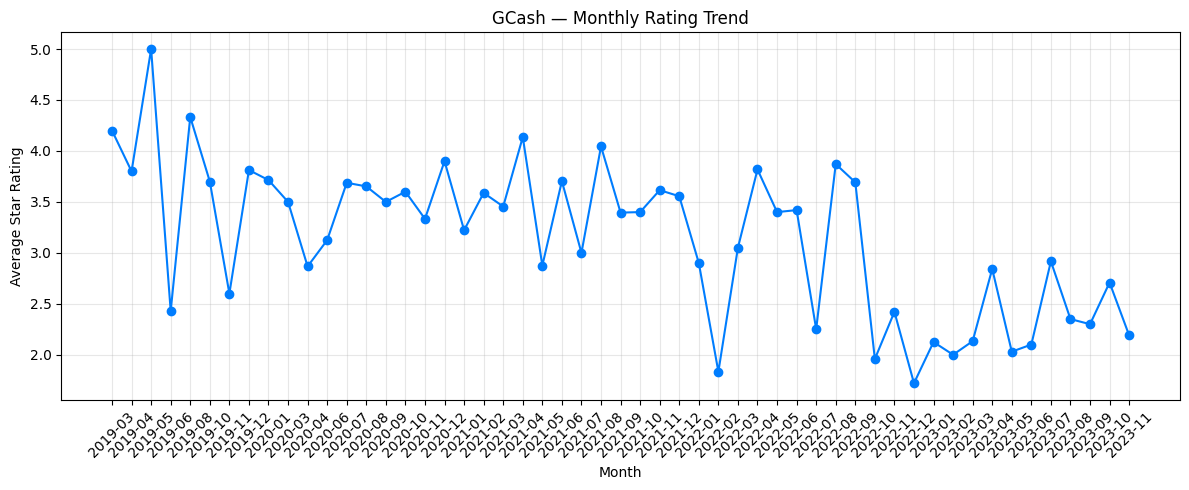

In [ ]:
# Filter to months with enough data
monthly = monthly[monthly['n_reviews'] >= 5]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly['year_month'], monthly['avg_rating'],
            marker='o', color='#007dfe', label='Avg Rating')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Star Rating')
ax1.tick_params(axis='y')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('GCash — Monthly Rating Trend')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q6: App version impact — do specific versions generate more complaints?
Business value: If rating drops after a release, that's a red flag for the engineering team.

In [ ]:
# Only look at versions with enough reviews to be meaningful
version_counts = df['author_app_version'].value_counts()
valid_versions = version_counts[version_counts >= 10].index

if len(valid_versions) > 0:
    version_stats = df[df['author_app_version'].isin(valid_versions)].groupby('author_app_version').agg(
        avg_rating=('review_rating', 'mean'),
        n_reviews=('review_rating', 'count')
    ).sort_values('n_reviews', ascending=False).round(2)

    print("Bottom 10 worst-rated app versions (min 10 reviews):\n")
    print(version_stats.head(10))
else:
    print("Not enough reviews per version for meaningful analysis")

Bottom 10 worst-rated app versions (min 10 reviews):

                    avg_rating  n_reviews
author_app_version                       
5.69.0                    2.19      13486
5.50.0                    3.40      10563
5.43.0                    3.73       9873
5.54.0                    3.36       8883
5.44.1                    3.32       8699
5.42.0                    4.04       7864
5.53.1                    3.28       7648
5.55.0                    3.12       7208
5.57.1                    2.40       7014
5.59.0                    2.16       6557


# Saving the Enriched Dataset

In [ ]:
output_path = '../data/gcash_reviews_enriched.csv'
df_sampled.to_csv(output_path, index=False)